In [9]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import torch
import torch.nn as nn
from torch.optim import Adam
from src.models.vit_transformer import get_vit
from src.datasets.road_loader import get_road_dl, organize_val_images
from tqdm import tqdm

In [10]:
num_classes = 27
model = get_vit(num_classes, pretrained=False)

# Check for Apple Silicon GPU (MPS)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using M4 GPU (MPS) acceleration!")
else:
    device = torch.device("cpu")
    print("MPS not available, using CPU.")

model.to(device)

Using M4 GPU (MPS) acceleration!


ByobNet(
  (stem): ConvNormAct(
    (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
  )
  (stages): Sequential(
    (0): Sequential(
      (0): BottleneckBlock(
        (conv1_1x1): ConvNormAct(
          (conv): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
        )
        (conv2_kxk): ConvNormAct(
          (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
   

In [11]:
# run this organization once, if validation images are not organized into class folders
# organize_val_images('/Users/jaspermatthe/Library/CloudStorage/OneDrive-UW/Documents/USA/UW/Courses/WIN26/EE562/EE562-Classifiers/data/road_surface/RSCD dataset-1million/vali_20k')

In [12]:
train_loader = get_road_dl('/Users/jaspermatthe/Library/CloudStorage/OneDrive-UW/Documents/USA/UW/Courses/WIN26/EE562/EE562-Classifiers/data/road_surface/RSCD dataset-1million/train', batch_size=32)
val_loader = get_road_dl('/Users/jaspermatthe/Library/CloudStorage/OneDrive-UW/Documents/USA/UW/Courses/WIN26/EE562/EE562-Classifiers/data/road_surface/RSCD dataset-1million/vali_20k', batch_size=32)

In [13]:
# Load test dataset
from src.datasets.road_loader import get_road_dl

test_loader = get_road_dl('/Users/jaspermatthe/Library/CloudStorage/OneDrive-UW/Documents/USA/UW/Courses/WIN26/EE562/EE562-Classifiers/data/road_surface/RSCD dataset-1million/test_50k', batch_size=32)

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-4)

In [15]:
scaler = torch.amp.GradScaler('mps') 

import os

# Initialize tracking variable
best_loss = float('inf')  
checkpoint_dir = '/Users/jaspermatthe/Library/CloudStorage/OneDrive-UW/Documents/USA/UW/Courses/WIN26/EE562/EE562-Classifiers/outputs/road_surface/checkpoints/'
os.makedirs(checkpoint_dir, exist_ok=True)

# --- LOAD PRE-EXISTING MODEL IF AVAILABLE ---
latest_path = os.path.join(checkpoint_dir, 'vit_rsxd_latest.pth')
if os.path.exists(latest_path):
    checkpoint = torch.load(latest_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    best_loss = checkpoint.get('loss', float('inf'))
    print(f"Loaded checkpoint from {latest_path}, epoch {checkpoint.get('epoch', '?')}, loss {best_loss:.4f}")

# for epoch in range(10):
#     model.train()
#     loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/10', unit='batch')
#     running_loss = 0.0
    
#     for images, labels in loop:
#         images, labels = images.to(device), labels.to(device)
#         optimizer.zero_grad()
        
#         with torch.amp.autocast(device_type='mps', dtype=torch.float16):
#             outputs = model(images)
#             loss = criterion(outputs, labels)
        
#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()
        
#         running_loss += loss.item()
#         loop.set_postfix(loss=f"{loss.item():.4f}")

#     avg_loss = running_loss / len(train_loader)
#     print(f'\nEpoch {epoch+1} Average Loss: {avg_loss:.4f}')

#     # --- SAVE LOGIC ---
#     checkpoint_data = {
#         'epoch': epoch + 1,
#         'model_state_dict': model.state_dict(),
#         'optimizer_state_dict': optimizer.state_dict(),
#         'scaler_state_dict': scaler.state_dict(),
#         'loss': avg_loss,
#     }

#     # 1. Save the "Latest" checkpoint (always overwrites)
#     torch.save(checkpoint_data, latest_path)

#     # 2. Save the "Best" checkpoint (only if loss improved)
#     if avg_loss < best_loss:
#         best_loss = avg_loss
#         best_path = os.path.join(checkpoint_dir, 'vit_rsxd_best.pth')
#         torch.save(checkpoint_data, best_path)
#         print(f"⭐ New best model saved with loss: {best_loss:.4f}")

Loaded checkpoint from /Users/jaspermatthe/Library/CloudStorage/OneDrive-UW/Documents/USA/UW/Courses/WIN26/EE562/EE562-Classifiers/outputs/road_surface/checkpoints/vit_rsxd_latest.pth, epoch 10, loss 0.2115


Evaluating: 100%|██████████| 1547/1547 [02:04<00:00, 12.47batch/s]


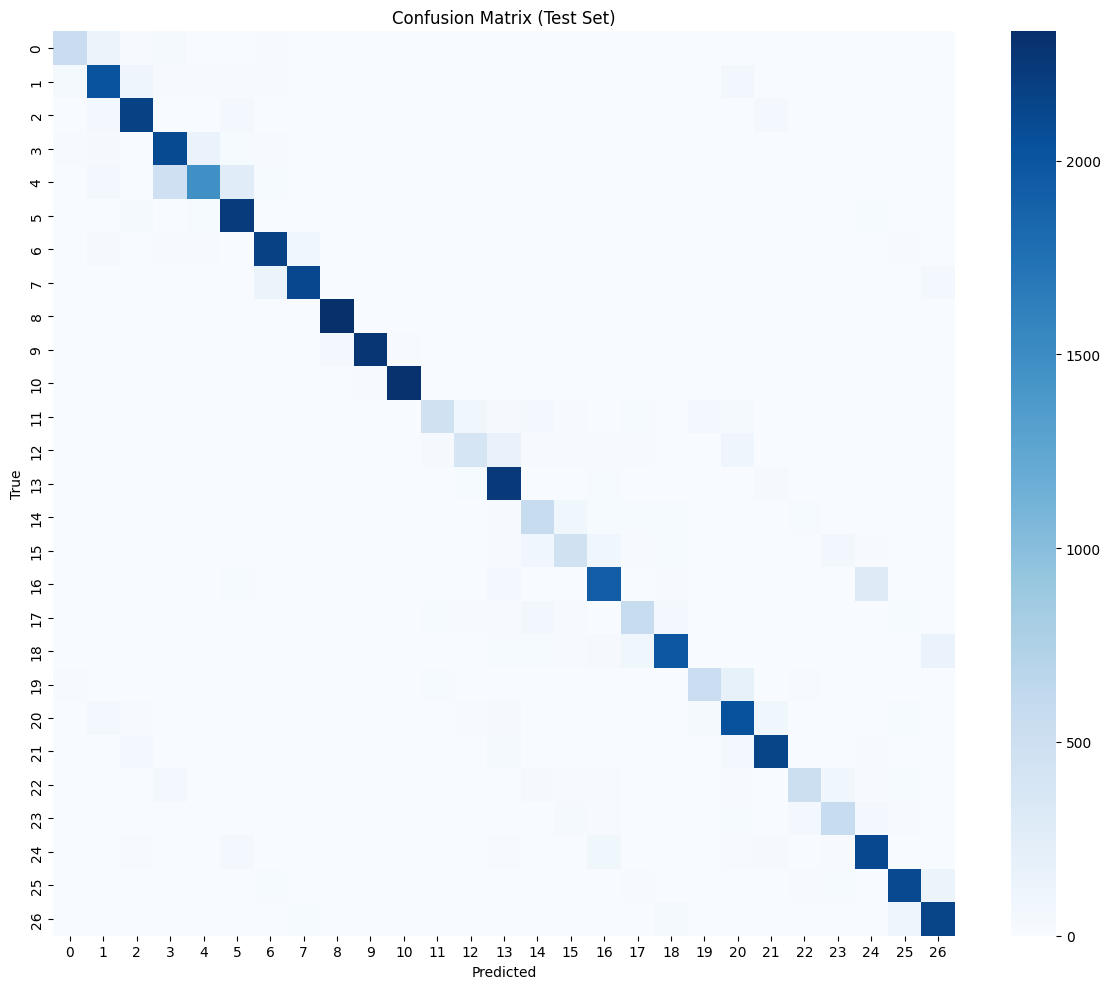

Mean class accuracy: 0.8114


In [16]:
# Evaluation: Confusion Matrix and Mean Class Accuracy on Test Set
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluating', unit='batch'):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

class_acc = cm.diagonal() / cm.sum(axis=1)
print(f"Mean class accuracy: {np.nanmean(class_acc):.4f}")